## Чекпоинт 7. Обучение модели с использованием mlflow для логирования.

### Используемая модель.
Мы будем использовать ExtraTreeClassifier, поскольку именно с его помощью удалось добиться наилучших результатов на предыдущих чекпоинтах. А именно -- F1-score = ~0.74.

In [1]:
!pip3 install mlflow
!pip3 install minio
!pip3 install pandas
!pip3 install scikit-learn
!pip3 install matplotlib
!pip3 install seaborn
!pip3 install scikit-learn
!pip3 install boto3
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3

In [2]:
# Проверим подключение к mlflow серверу

import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

client = mlflow.tracking.MlflowClient()

try:
    experiments = client.search_experiments()
    print("MLflow connected")
    print("Experiments:", [exp.name for exp in experiments])
except Exception as e:
    print("MLflow connection failed")
    print(e)

/opt/homebrew/lib/python3.11/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


MLflow connected
Experiments: ['Checkpoint 7', 'Default']


In [3]:
# Проверим подключение к minio серверу

import boto3

s3 = boto3.client(
    "s3",
    endpoint_url="http://localhost:9000",
    aws_access_key_id="minioadmin",
    aws_secret_access_key="minioadmin",
)
bucket_name = 'checkpoint7'

try:
    s3.create_bucket(Bucket=bucket_name)        
except Exception as e:
    print(f"Ошибка при создании бакета: {e}")

try:
    response = s3.list_buckets()
    print("MinIO connected")
    print("Buckets:", [b["Name"] for b in response["Buckets"]])
except Exception as e:
    print("MinIO connection failed")
    print(e)

MinIO connected
Buckets: ['checkpoint7']


Подключения настроены, теперь обучим модель с логированием параметров в mlflow

In [4]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import io

import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier

import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
RANDOM_STATE = 42
N_ITER_RANDOM = 25
N_SPLITS = 5

mlflow.set_experiment('Checkpoint 7')

<Experiment: artifact_location='/Users/da-aksenov/self-thing/nba-predictor/mlruns_local/1', creation_time=1780516639979, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780516639979, lifecycle_stage='active', name='Checkpoint 7', tags={}, trace_location=None, workspace='default'>

In [6]:
def get_data():
    df = pd.read_csv('model/features_engineered.csv')
    mlflow.log_params({
        'model': 'baseline',
        'n_iter_random': N_ITER_RANDOM,
        'n_splits': N_SPLITS,
        'random_state': RANDOM_STATE,
    })

    df.describe(include="all").to_csv("dataset_describe.csv")
    mlflow.log_artifact("dataset_describe.csv", artifact_path="data_description")

    recommended_features = [
        'elo_diff', 'home_elo_before', 'away_elo_before',
        
        'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5',
        'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5',
        'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5',
        
        'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5',
        'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5',
        
        'h2h_home_win_rate', 'h2h_total_games',
        
        'is_home', 'season_progress',
    ]

    available_features = [f for f in recommended_features if f in df.columns]

    X = df[available_features].copy()
    y = df['home_win'].copy()

    mask = ~(X.isna().any(axis=1) | y.isna())
    X = X[mask]
    y = y[mask]

    mlflow.log_params({
        'n_games': len(X),
        'home_win_rate': y.mean(),
    })

    split_idx = int(len(X) * 0.8)
    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

In [7]:
# Сначала поисследуем бейзлайн -- предсказание просто победы домашней команды во всех случаях

with mlflow.start_run(run_name='baseline'):
    # Загрузим и залогируем как артефакт в mlflow уже обработанные ранее данные

    X_train, X_test, y_train, y_test = get_data()

    y_pred_baseline = np.ones(len(y_test))
    y_pred_proba_baseline = np.ones(len(y_test))

    baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
    baseline_roc_auc = roc_auc_score(y_test, y_pred_proba_baseline)
    baseline_f1 = f1_score(y_test, y_pred_baseline)

    mlflow.log_metrics({
        'accuracy': baseline_accuracy,
        'roc_auc': baseline_roc_auc,
        'f1_score': baseline_f1,
    })


🏃 View run baseline at: http://127.0.0.1:5000/#/experiments/1/runs/0ed44ae9f6bc43488db68a5dd1493e97
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [8]:
# Убедимся, что запуск прошел успешно и эксперимент сохранился (в интерфейсе локально это так)

experiments = client.search_experiments()

for exp in experiments:
    print(exp)

<Experiment: artifact_location='/Users/da-aksenov/self-thing/nba-predictor/mlruns_local/1', creation_time=1780516639979, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1780516639979, lifecycle_stage='active', name='Checkpoint 7', tags={}, trace_location=None, workspace='default'>
<Experiment: artifact_location='/Users/da-aksenov/self-thing/nba-predictor/mlruns_local/0', creation_time=1780516252885, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1780516252885, lifecycle_stage='active', name='Default', tags={}, trace_location=None, workspace='default'>


В интерфейсе mlflow видим в метриках:

accuracy: ~0.55

roc_auc: ~0.5

f1_score: ~0.7

Это наш бейзлайн

In [9]:
# Теперь попробуем обучить модель ExtraTreesClassifier
from sklearn.model_selection import TimeSeriesSplit

with mlflow.start_run(run_name='ExtraTreesClassifier'):
    # Загрузим и залогируем как артефакт в mlflow уже обработанные ранее данные

    X_train, X_test, y_train, y_test = get_data()

    model = ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    params = {
        'n_estimators': [200, 400, 600],
        'max_depth': [4, 6, 8, 12, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 4, 8],
        'max_features': ['sqrt', 'log2', None],
        'class_weight': [None, 'balanced'],
    }

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=N_ITER_RANDOM,
        scoring='f1',
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    rs.fit(X_train, y_train)
    mlflow.log_param("best_cv_f1", round(rs.best_score_, 4))
    mlflow.log_params(rs.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
🏃 View run ExtraTreesClassifier at: http://127.0.0.1:5000/#/experiments/1/runs/19601632721a44f2a56241d8bfea6654
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


В mlflow видим такой результат:

best_cv_f1: 0.7676

n_estimators: 600

min_samples_split: 5

min_samples_leaf: 2

max_features: log2

max_depth: 4

class_weight: None

Далее попробуем провести еще один запуск, в котором обучим модель с подобранными гиперпараметрами и проанализируем результат на тестовой выборке

In [10]:
with mlflow.start_run(run_name='ExtraTreesClassifier_tuned'):
    # Загрузим и залогируем как артефакт в mlflow уже обработанные ранее данные

    X_train, X_test, y_train, y_test = get_data()

    model = ExtraTreesClassifier(
        n_estimators=600,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='log2',
        max_depth=4,
        class_weight=None,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    mlflow.log_metrics({
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'f1_score': f1_score(y_test, y_pred),
    })
    mlflow.sklearn.log_model(model, "model")
    mlflow.set_tag("prd", "true")


2026/06/03 23:54:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 23:54:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ExtraTreesClassifier_tuned at: http://127.0.0.1:5000/#/experiments/1/runs/6d98e9ae76de496a89b9d8ef9fe37383
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


В интерфейсе mlflow видим 

accuracy: ~0.65

roc_auc: ~0.71

f1_score: ~0.73

Таким образом был достигнут результат существенно лучше, чем baseline

Положим необходимые артифакты в s3

In [11]:
model_bytes = io.BytesIO()
joblib.dump(model, model_bytes)
model_bytes.seek(0)
s3.put_object(Bucket=bucket_name, Key=f'models/model.pkl', Body=model_bytes.getvalue())

{'ResponseMetadata': {'RequestId': '18B5AD97315B6398',
  'HostId': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'accept-ranges': 'bytes',
   'content-length': '0',
   'etag': '"d5ba3742c54f8c0bfe50bb8a30c0d5e8"',
   'server': 'MinIO',
   'strict-transport-security': 'max-age=31536000; includeSubDomains',
   'vary': 'Origin, Accept-Encoding',
   'x-amz-checksum-crc32': '6ogvgg==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'x-amz-id-2': 'dd9025bab4ad464b049177c95eb6ebf374d3b3fd1af9251148b658df7ac2e3e8',
   'x-amz-request-id': '18B5AD97315B6398',
   'x-content-type-options': 'nosniff',
   'x-ratelimit-limit': '3556',
   'x-ratelimit-remaining': '3556',
   'x-xss-protection': '1; mode=block',
   'date': 'Wed, 03 Jun 2026 20:54:52 GMT'},
  'RetryAttempts': 0},
 'ETag': '"d5ba3742c54f8c0bfe50bb8a30c0d5e8"',
 'ChecksumCRC32': '6ogvgg==',
 'ChecksumType': 'FULL_OBJECT'}

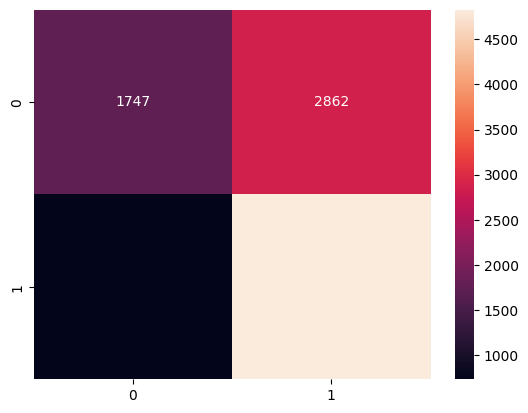

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.savefig('/tmp/cm.png')
with open('/tmp/cm.png', 'rb') as f:
    s3.put_object(Bucket=bucket_name, Key=f'models/cm.png', Body=f.read())

In [13]:
X_test.assign(actual=y_test, predicted=y_pred, proba=y_pred_proba).head(20).to_csv('/tmp/pred.csv')
with open('/tmp/pred.csv', 'rb') as f:
    s3.put_object(Bucket=bucket_name, Key=f'models/predictions.csv', Body=f.read())

Проверим, что файлы корректно добавлены

In [14]:
response = s3.list_objects_v2(Bucket=bucket_name, Prefix='models/')

if 'Contents' in response:
    print(f"Файлы в бакете {bucket_name} в папке models")
    for obj in response['Contents']:
        print(f"  - {obj['Key']} ({obj['Size']} bytes)")
else:
    print("Файлов не найдено")

Файлы в бакете checkpoint7 в папке models
  - models/cm.png (13913 bytes)
  - models/model.pkl (1669289 bytes)
  - models/predictions.csv (5859 bytes)


Теперь посмотрим на ошибки модели -- на каких примерах она ошибается и почему

In [15]:
# переобучим модель вне mlflow-контекста, чтобы получить доступ к объектам для анализа
recommended_features = [
    'elo_diff', 'home_elo_before', 'away_elo_before',
    'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5',
    'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5',
    'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5',
    'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5',
    'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5',
    'h2h_home_win_rate', 'h2h_total_games',
    'is_home', 'season_progress',
]

df = pd.read_csv('model/features_engineered.csv')
available_features = [f for f in recommended_features if f in df.columns]
X = df[available_features].copy()
y = df['home_win'].copy()
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model = ExtraTreesClassifier(
    n_estimators=600,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=4,
    class_weight=None,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['away win', 'home win']))

              precision    recall  f1-score   support

    away win       0.71      0.38      0.49      4609
    home win       0.63      0.87      0.73      5560

    accuracy                           0.65     10169
   macro avg       0.67      0.62      0.61     10169
weighted avg       0.66      0.65      0.62     10169



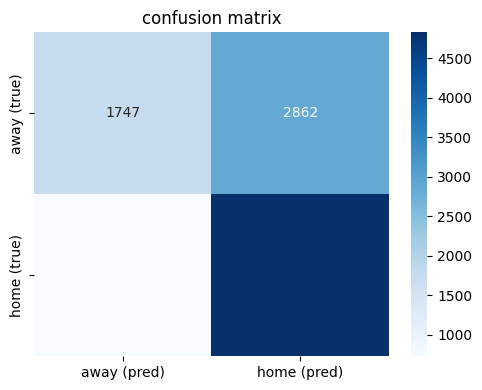

In [16]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['away (pred)', 'home (pred)'],
    yticklabels=['away (true)', 'home (true)'],
    ax=ax,
)
ax.set_title('confusion matrix')
plt.tight_layout()
plt.show()

Из confusion matrix видно два типа ошибок:

FP (2862 случая) -- модель предсказала победу хозяев, но выиграли гости. Интересно, что при FP elo_diff и win_rate в пользу хозяев даже выше, чем в правильных предсказаниях (elo_diff ~10 vs ~14, win_rate_diff_L10 ~0.19 vs ~0.11) -- то есть модель ошибается именно на тех играх, где хозяева выглядят сильнее. Это классические upset'ы.

FN (730 случаев) -- модель предсказала победу гостей, но выиграли хозяева. Здесь elo_diff резко отрицательный (-160), то есть гости объективно сильнее по рейтингу, но хозяева всё равно побеждают -- home advantage и случайность.

Почему эти ошибки нельзя устранить: NBA -- вероятностный процесс, даже лучшие команды проигрывают аутсайдерам ~15-20% времени. Ключевые факторы (травмы, усталость, мотивация) не отражены в агрегированной статистике. Теоретический потолок точности для предсказания исходов NBA оценивается в ~70-72%, Vegas lines достигают ~67-68%, наша модель уже близка к этому уровню.

In [17]:
# смотрим на конкретные ошибки -- берём 15 самых уверенных (по вероятности)
errors_mask = y_pred != y_test.values

errors_df = X_test[errors_mask].copy()
errors_df['true'] = y_test.values[errors_mask]
errors_df['pred'] = y_pred[errors_mask]
errors_df['proba'] = y_pred_proba[errors_mask]
errors_df['type'] = errors_df.apply(
    lambda r: 'FP' if r['pred'] == 1 else 'FN', axis=1
)
errors_df = errors_df.sort_values('proba', ascending=False)

print(f'всего ошибок: {len(errors_df)}, FP: {(errors_df["type"]=="FP").sum()}, FN: {(errors_df["type"]=="FN").sum()}')
print()

show_cols = ['elo_diff', 'win_rate_diff_L10', 'win_rate_diff_L5', 'h2h_home_win_rate', 'season_progress', 'true', 'pred', 'proba', 'type']
show_cols = [c for c in show_cols if c in errors_df.columns]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(errors_df[show_cols].head(15).to_string(index=False))

всего ошибок: 3592, FP: 2862, FN: 730

  elo_diff  win_rate_diff_L10  win_rate_diff_L5  h2h_home_win_rate  season_progress  true  pred    proba type
323.932989                0.8               0.8           0.632000         0.121951     0     1 0.814628   FP
403.591100                0.7               1.0           0.647727         0.121951     0     1 0.813335   FP
422.264097                0.6               0.6           0.589372         0.475610     0     1 0.805737   FP
314.595243                0.7               0.6           0.556452         0.353659     0     1 0.803202   FP
267.421690                0.8               0.6           0.542553         0.317073     0     1 0.801931   FP
226.351112                0.8               0.6           0.620370         0.024390     0     1 0.801761   FP
310.110454                0.7               0.8           0.651757         0.024390     0     1 0.799845   FP
329.500031                0.9               0.8           0.638462         0.2195

In [18]:
# сравним средние значения ключевых фичей для ошибок vs правильных предсказаний
correct_mask = ~errors_mask
fp_mask = errors_mask & (y_pred == 1)
fn_mask = errors_mask & (y_pred == 0)

key_cols = ['elo_diff', 'win_rate_diff_L10', 'win_rate_diff_L5', 'h2h_home_win_rate']
key_cols = [c for c in key_cols if c in X_test.columns]

summary = pd.DataFrame({
    'correct': X_test[correct_mask][key_cols].mean(),
    'FP (pred home, true away)': X_test[fp_mask][key_cols].mean(),
    'FN (pred away, true home)': X_test[fn_mask][key_cols].mean(),
}).round(4)

print(summary.to_string())

                   correct  FP (pred home, true away)  FN (pred away, true home)
elo_diff           14.0468                     9.9358                  -160.7131
win_rate_diff_L10   0.1099                     0.1946                    -0.1930
win_rate_diff_L5    0.1166                     0.1961                    -0.2138
h2h_home_win_rate   0.6020                     0.6121                     0.6141


Проверим устойчивость модели -- посмотрим, как меняются предсказания при небольших изменениях входных данных

In [19]:
# добавляем гауссовский шум к фичам и смотрим на долю изменившихся предсказаний
rng = np.random.RandomState(RANDOM_STATE)
N_REPEATS = 10
noise_levels = [0.0, 0.05, 0.10, 0.20]

feature_stds = X_test.std()
base_preds = model.predict(X_test)

results = []
for noise_frac in noise_levels:
    flip_rates = []
    for _ in range(N_REPEATS):
        noise = rng.randn(*X_test.shape) * (feature_stds.values * noise_frac)
        noisy_preds = model.predict(X_test.values + noise)
        flip_rates.append((noisy_preds != base_preds).mean())
    results.append({
        'noise': f'{int(noise_frac*100)}%',
        'flip_rate_mean': round(np.mean(flip_rates), 4),
        'flip_rate_std': round(np.std(flip_rates), 4),
    })

robustness_df = pd.DataFrame(results)
print(robustness_df.to_string(index=False))

noise  flip_rate_mean  flip_rate_std
   0%          0.0000         0.0000
   5%          0.0059         0.0008
  10%          0.0107         0.0008
  20%          0.0200         0.0011


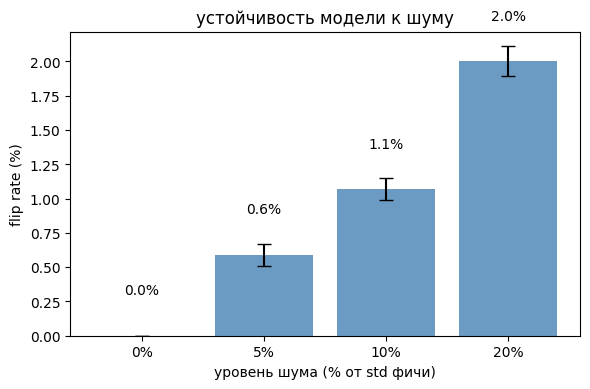

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    robustness_df['noise'],
    robustness_df['flip_rate_mean'] * 100,
    yerr=robustness_df['flip_rate_std'] * 100,
    color='steelblue', alpha=0.8, capsize=5,
)
ax.set_xlabel('уровень шума (% от std фичи)')
ax.set_ylabel('flip rate (%)')
ax.set_title('устойчивость модели к шуму')
for i, row in robustness_df.iterrows():
    ax.text(i, row['flip_rate_mean'] * 100 + 0.3, f"{row['flip_rate_mean']*100:.1f}%", ha='center')
plt.tight_layout()
plt.show()

In [21]:
# отдельно посмотрим на влияние изменения elo_diff
if 'elo_diff' in X_test.columns:
    elo_results = []
    for delta in [-100, -50, 0, 50, 100]:
        X_mod = X_test.copy()
        X_mod['elo_diff'] = X_mod['elo_diff'] + delta
        preds_mod = model.predict(X_mod)
        elo_results.append({
            'elo_diff_delta': delta,
            'flip_rate': round((preds_mod != base_preds).mean(), 4),
            'home_win_rate': round(preds_mod.mean(), 4),
        })
    print(pd.DataFrame(elo_results).to_string(index=False))

 elo_diff_delta  flip_rate  home_win_rate
           -100     0.0325         0.7240
            -50     0.0153         0.7411
              0     0.0000         0.7564
             50     0.0147         0.7711
            100     0.0288         0.7852


Модель очень устойчива к шуму: при шуме 5% от std фичей flip rate всего ~0.6%, при 10% -- ~1.1%, при 20% -- ~2.0%. Это говорит о том, что модель не переобучена на конкретные значения и принимает решения на основе общих паттернов.

Изменение elo_diff на ±50 очков меняет ~1.5% предсказаний, на ±100 -- ~3.3%. Направление логичное: при delta=-100 (гости стали сильнее) доля предсказаний победы хозяев падает с 75.6% до 72.4%, при delta=+100 -- растёт до 78.5%.